<a href="https://colab.research.google.com/github/joaocanaslopes/AV_project-/blob/main/calculate_SPI_some_analises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
from scipy.stats import gamma, norm

# -----------------------------
# 1. função SPI-12
# -----------------------------
def calculate_spi_12(df):
    df = df.copy()

    # garantir datetime
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date')

    # precipitação mensal
    df['precip'] = df['precipitation']

    # rolling 12 meses (SPI-12 base)
    df['precip_12m'] = df['precip'].rolling(12).sum()

    # remover nans iniciais
    data = df.dropna(subset=['precip_12m']).copy()

    # ajustar distribuição gamma
    # (SPI clássico usa gamma para precipitação)
    shape, loc, scale = gamma.fit(data['precip_12m'], floc=0)

    # CDF gamma
    cdf = gamma.cdf(data['precip_12m'], shape, loc=loc, scale=scale)

    # evitar 0 e 1 extremos
    cdf = np.clip(cdf, 1e-6, 1 - 1e-6)

    # transformar para normal padrão (SPI)
    data['spi_12'] = norm.ppf(cdf)

    return data[['date', 'spi_12']]

def preprocess_precipitation_data(df):
    # Identify monthly precipitation columns
    month_cols = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    # Melt the dataframe to long format
    df_melted = df.melt(id_vars=['year'], value_vars=month_cols, var_name='month', value_name='precipitation')

    # Map month names to numbers
    month_mapping = {'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6, 'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12}
    df_melted['month_num'] = df_melted['month'].map(month_mapping)

    # Create a 'date' column
    df_melted['date'] = pd.to_datetime(df_melted['year'].astype(str) + '-' + df_melted['month_num'].astype(str) + '-01')

    # Select relevant columns and sort by date
    df_transformed = df_melted[['date', 'precipitation']].sort_values('date').reset_index(drop=True)

    return df_transformed


# -----------------------------
# 2. carregar dados
# -----------------------------
beja_raw = pd.read_csv("https://raw.githubusercontent.com/joaocanaslopes/AV_project-/refs/heads/main/prec-Beja-raw.csv")
faro_raw = pd.read_csv("https://raw.githubusercontent.com/joaocanaslopes/AV_project-/refs/heads/main/prec-Faro.csv")

# -----------------------------
# 3. Preprocess data and calculate SPI-12
# -----------------------------
beja_preprocessed = preprocess_precipitation_data(beja_raw)
faro_preprocessed = preprocess_precipitation_data(faro_raw)

spi_beja = calculate_spi_12(beja_preprocessed)
spi_faro = calculate_spi_12(faro_preprocessed)

# -----------------------------
# 4. transformar em ANUAL
# -----------------------------
spi_beja['year'] = spi_beja['date'].dt.year
spi_faro['year'] = spi_faro['date'].dt.year

beja_year = spi_beja.groupby('year')['spi_12'].mean().reset_index()
faro_year = spi_faro.groupby('year')['spi_12'].mean().reset_index()

# -----------------------------
# 5. adicionar região
# -----------------------------
beja_year['region'] = 'Alentejo'
faro_year['region'] = 'Algarve'

# -----------------------------
# 6. juntar tudo
# -----------------------------
final = pd.concat([beja_year, faro_year])

# filtrar 2005-2018
final = final[(final['year'] >= 2005) & (final['year'] <= 2018)]

# renomear
final = final.rename(columns={'year': 'ano'})

print(final)

      ano    spi_12    region
104  2005 -2.644939  Alentejo
105  2006 -0.455890  Alentejo
106  2007 -0.234146  Alentejo
107  2008 -0.646842  Alentejo
108  2009 -0.834508  Alentejo
109  2010  0.833810  Alentejo
110  2011  1.054520  Alentejo
111  2012 -0.645939  Alentejo
112  2013 -0.399869  Alentejo
113  2014 -0.497723  Alentejo
114  2015  0.132113  Alentejo
115  2016  0.467278  Alentejo
116  2017  0.256928  Alentejo
117  2018 -0.479544  Alentejo
39   2005 -2.017008   Algarve
40   2006  0.297135   Algarve
41   2007 -0.051059   Algarve
42   2008  0.322800   Algarve
43   2009 -0.465511   Algarve
44   2010  1.050557   Algarve
45   2011  0.697272   Algarve
46   2012 -0.900856   Algarve
47   2015 -0.887075   Algarve
48   2016 -0.335696   Algarve
49   2017 -0.000569   Algarve
50   2018 -0.335639   Algarve


In [4]:
final.to_csv('final_spi_12.csv', index=False)

In [5]:
import pandas as pd

# Load the existing final_table.csv from the provided URL
final_table_df = pd.read_csv('https://raw.githubusercontent.com/joaocanaslopes/AV_project-/refs/heads/main/final_table.csv')

# Rename 'year' column to 'ano' in final_table_df to match the 'final' DataFrame
final_table_df = final_table_df.rename(columns={'year': 'ano'})

# Merge the spi_12 column from the 'final' DataFrame
# An inner merge ensures that only rows with matching 'ano' and 'region' exist in the output,
# thus preventing unpopulated spi_12 values from non-matches.
updated_final_table_df = pd.merge(
    final_table_df,
    final[['ano', 'region', 'spi_12']],
    on=['ano', 'region'],
    how='inner'
)

# Save the updated DataFrame back to final_table.csv
updated_final_table_df.to_csv('final_table.csv', index=False)

print("Updated 'final_table.csv' with 'spi_12' column.")
print(updated_final_table_df.head())

Updated 'final_table.csv' with 'spi_12' column.
    ano    region            species  area_ha  production_t  \
0  2018  Alentejo  Cereais para grão  99278.0      369821.0   
1  2018  Alentejo              Trigo  18631.0       47839.0   
2  2018  Alentejo         Trigo mole  14677.0       37133.0   
3  2018  Alentejo         Trigo duro   3955.0       10706.0   
4  2018  Alentejo            Centeio    112.0         134.0   

   productivity_kg_ha  irrigable_area_ha  precipitation_mm  mean_temp  \
0         3725.105260           175410.0             570.0      16.59   
1         2567.709731           175410.0             570.0      16.59   
2         2530.012945           175410.0             570.0      16.59   
3         2706.953224           175410.0             570.0      16.59   
4         1196.428571           175410.0             570.0      16.59   

   mean_tmax  mean_tmin  annual_precipitation_anomaly    spi_12  
0  22.610833      10.57                         43.55 -0.479544  
1 

In [6]:
updated_final_table_df.to_csv('total_com_spi12.csv', index=False)
print("Saved 'total_com_spi12.csv' successfully.")

Saved 'total_com_spi12.csv' successfully.


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carrega o DataFrame a partir do CSV (se você estiver começando uma nova sessão ou célula)
df= pd.read_csv('total_com_spi12.csv')

display(df.head())

,ano,region,species,area_ha,production_t,productivity_kg_ha,irrigable_area_ha,precipitation_mm,mean_temp,mean_tmax,mean_tmin,annual_precipitation_anomaly,spi_12
0,2018,Alentejo,Cereais para grão,99278.0,369821.0,3725.105260,175410.0,570.0,16.59,22.610833,10.57,43.55,-0.479544
1,2018,Alentejo,Trigo,18631.0,47839.0,2567.709731,175410.0,570.0,16.59,22.610833,10.57,43.55,-0.479544
2,2018,Alentejo,Trigo mole,14677.0,37133.0,2530.012945,175410.0,570.0,16.59,22.610833,10.57,43.55,-0.479544
3,2018,Alentejo,Trigo duro,3955.0,10706.0,2706.953224,175410.0,570.0,16.59,22.610833,10.57,43.55,-0.479544
4,2018,Alentejo,Centeio,112.0,134.0,1196.428571,175410.0,570.0,16.59,22.610833,10.57,43.55,-0.479544


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2444 entries, 0 to 2443
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ano                           2444 non-null   int64  
 1   region                        2444 non-null   object 
 2   species                       2444 non-null   object 
 3   area_ha                       2444 non-null   float64
 4   production_t                  2444 non-null   float64
 5   productivity_kg_ha            2444 non-null   float64
 6   irrigable_area_ha             2444 non-null   float64
 7   precipitation_mm              2444 non-null   float64
 8   mean_temp                     2444 non-null   float64
 9   mean_tmax                     2444 non-null   float64
 10  mean_tmin                     2444 non-null   float64
 11  annual_precipitation_anomaly  2444 non-null   float64
 12  spi_12                        2444 non-null   float64
dtypes: 

Agora, vamos visualizar o `spi_12` médio por ano e região usando um gráfico de linha.

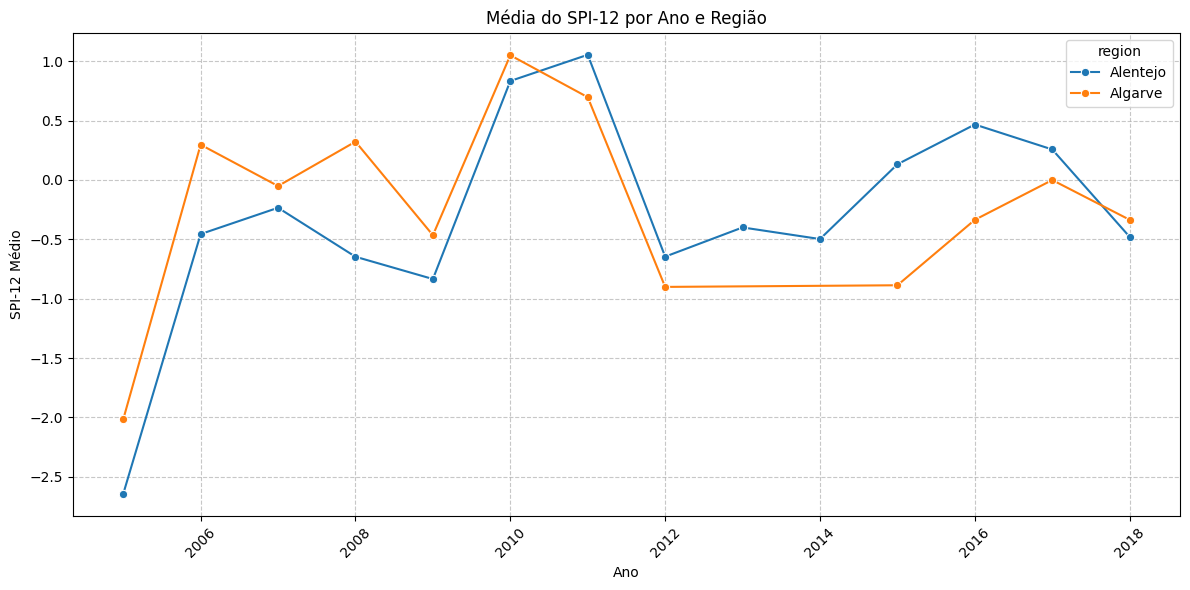

In [9]:
# Calcula o SPI-12 médio por ano e região para visualização
avg_spi_by_year_region = df.groupby(['ano', 'region'])['spi_12'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=avg_spi_by_year_region, x='ano', y='spi_12', hue='region', marker='o')
plt.title('Média do SPI-12 por Ano e Região')
plt.xlabel('Ano')
plt.ylabel('SPI-12 Médio')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
import plotly.express as px

# Assuming 'df' is already loaded from 'total_com_spi12.csv'
# If not, uncomment the line below:
# df = pd.read_csv('total_com_spi12.csv')

fig = px.scatter(df,
                 x='spi_12',
                 y='productivity_kg_ha',
                 color='region',
                 hover_data=df.columns, # Display all columns on hover
                 title='Gráfico de Pontos da Produtividade vs SPI-12 por Região com Detalhes ao Passar o Mouse')

fig.update_layout(xaxis_title='SPI-12', yaxis_title='Produtividade (kg/ha)')
fig.show()

In [11]:
import plotly.express as px

# Assuming 'df' is already loaded from 'total_com_spi12.csv'
# If not, uncomment the line below:
# df = pd.read_csv('total_com_spi12.csv')

fig = px.scatter(df,
                 x='spi_12',
                 y='production_t',
                 color='region',
                 hover_data=df.columns, # Display all columns on hover
                 title='Gráfico de Pontos da Produção Total vs SPI-12 por Região com Detalhes ao Passar o Mouse')

fig.update_layout(xaxis_title='SPI-12', yaxis_title='Produção Total (toneladas)')
fig.show()

In [ ]:
import plotly.express as px

# Create a scatter plot for SPI-12 vs. Productivity (kg/ha)
fig = px.scatter(df,
                 x='spi_12',
                 y='productivity_kg_ha',
                 color='region',
                 hover_data=df.columns, # Display all columns on hover
                 title='Correlação entre SPI-12 e Produtividade por Hectare por Região')

fig.update_layout(xaxis_title='SPI-12', yaxis_title='Produtividade (kg/ha)')
fig.show()

# Calculate the Pearson correlation coefficient
correlation = df['spi_12'].corr(df['productivity_kg_ha'])
print(f"\nCoeficiente de Correlação de Pearson entre SPI-12 e Produtividade (kg/ha): {correlation:.3f}")


Coeficiente de Correlação de Pearson entre SPI-12 e Produtividade (kg/ha): 0.014


In [ ]:
import pandas as pd
import numpy as np

# Get unique regions
unique_regions = df['region'].unique()

for region_name in unique_regions:
    print(f"\n--- Análise para a Região: {region_name} ---")

    # Filtrar dados para a região atual
    df_region = df[df['region'] == region_name].copy()

    # Filtrar dados para valores baixos de spi_12 (por exemplo, SPI-12 < -1.0 para seca moderada a extrema)
    df_drought = df_region[df_region['spi_12'] < -1.0].copy()

    # Calcular a produtividade média por hectare para cada espécie durante a seca na região
    avg_prod_drought = df_drought.groupby('species')['productivity_kg_ha'].mean().reset_index()
    avg_prod_drought = avg_prod_drought.rename(columns={'productivity_kg_ha': 'produtividade_media_seca_kg_ha'})

    # Calcular a produtividade média geral por hectare para cada espécie na região
    overall_avg_prod = df_region.groupby('species')['productivity_kg_ha'].mean().reset_index()
    overall_avg_prod = overall_avg_prod.rename(columns={'productivity_kg_ha': 'produtividade_media_geral_kg_ha'})

    # Juntar os dois dataframes
    comparison_df = pd.merge(overall_avg_prod, avg_prod_drought, on='species', how='left')

    # Preencher NaN na produtividade_media_seca_kg_ha com a produtividade_media_geral_kg_ha
    comparison_df['produtividade_media_seca_kg_ha'] = comparison_df['produtividade_media_seca_kg_ha'].fillna(comparison_df['produtividade_media_geral_kg_ha'])

    # Calcular a queda de produtividade devido à seca
    comparison_df['queda_produtividade_kg_ha'] = comparison_df['produtividade_media_geral_kg_ha'] - comparison_df['produtividade_media_seca_kg_ha']

    # Calcular a queda percentual
    comparison_df['queda_percentual'] = (comparison_df['queda_produtividade_kg_ha'] / comparison_df['produtividade_media_geral_kg_ha']) * 100
    comparison_df['queda_percentual'] = comparison_df['queda_percentual'].replace([np.inf, -np.inf], np.nan)
    comparison_df = comparison_df.fillna(0)

    # Filtrar apenas as espécies que tiveram queda na produtividade (queda_percentual > 0)
    most_affected_species = comparison_df[comparison_df['queda_percentual'] > 0]

    # Ordenar pela queda percentual em ordem decrescente para ver as mais afetadas primeiro
    most_affected_species = most_affected_species.sort_values(by='queda_percentual', ascending=False)

    if not most_affected_species.empty:
        print(f"Espécies mais afetadas negativamente por SPI-12 baixo (secas moderadas a extremas, SPI-12 < -1.0) em {region_name}:")
        display(most_affected_species.round(2))
    else:
        print(f"Não foram encontradas espécies afetadas negativamente por SPI-12 baixo em {region_name}, ou não há dados de seca para comparação.")


--- Análise para a Região: Alentejo ---
Espécies mais afetadas negativamente por SPI-12 baixo (secas moderadas a extremas, SPI-12 < -1.0) em Alentejo:


,species,produtividade_media_geral_kg_ha,produtividade_media_seca_kg_ha,queda_produtividade_kg_ha,queda_percentual
6,Amoras,1588.51,0.00,1588.51,100.00
11,Aveia forrageira,11141.70,0.00,11141.70,100.00
59,Milho forrageiro,30269.52,0.00,30269.52,100.00
78,Romã,2313.27,0.00,2313.27,100.00
70,Principais culturas forrageiras,12509.04,0.00,12509.04,100.00
62,Mirtilos,1067.00,0.00,1067.00,100.00
44,Frutos pequenos de baga,1507.82,0.00,1507.82,100.00
48,Groselha,392.86,0.00,392.86,100.00
43,Framboesas,1642.86,0.00,1642.86,100.00
20,Castanha,1732.98,200.75,1532.23,88.42



--- Análise para a Região: Algarve ---
Espécies mais afetadas negativamente por SPI-12 baixo (secas moderadas a extremas, SPI-12 < -1.0) em Algarve:


,species,produtividade_media_geral_kg_ha,produtividade_media_seca_kg_ha,queda_produtividade_kg_ha,queda_percentual
6,Amoras,783.33,0.00,783.33,100.00
9,Arroz,4382.93,0.00,4382.93,100.00
11,Aveia forrageira,9198.97,0.00,9198.97,100.00
62,Mirtilos,1291.67,0.00,1291.67,100.00
43,Framboesas,1498.80,0.00,1498.80,100.00
70,Principais culturas forrageiras,9629.88,0.00,9629.88,100.00
59,Milho forrageiro,20525.59,0.00,20525.59,100.00
44,Frutos pequenos de baga,1483.74,0.00,1483.74,100.00
18,Batata de sequeiro,7987.68,250.00,7737.68,96.87
88,Triticale,943.72,228.81,714.91,75.75
